# Heatmaps — interaction hétérogène vs référence homogène

Ce notebook reproduit les **12 heatmaps** présents dans le mémoire. Le solveur, les métriques et les contrôles de convergence sont importés depuis `mfg_liquidation`.

Pour chaque scénario, les cartes représentent pour la sous-population 1:

$$
\Delta M = M_{\text{interaction hétérogène}} - M_{\text{référence homogène}}
$$

Les couleurs sont orientées de façon à ce que **le vert indique une évolution favorable pour la sous-population 1**, **le rouge une évolution défavorable** et **le bleu un écart nul ou proche de zéro**.

- **Indice unitaire d'impact permanent** : $\Delta>0$ signifie que l'interaction hétérogène améliore le prix moyen des transactions à travers l'impact permanent.
- **Coût temporaire unitaire** : $\Delta<0$ correspond à un coût plus faible en interaction.
- **Exposition au risque de prix normalisée** : $\Delta<0$ correspond à une exposition cumulée plus faible.
- **Distance à zéro de l’inventaire terminal** : $\Delta<0$ correspond à moins d'inventaire résiduel et donc davantage de liquidation.

Sur la diagonale de chaque scénario, les deux sous-populations ont les mêmes paramètres, l'interaction redevient homogène et les écarts doivent être égale à zéro.

Les paramètres de base et les plages testés sont: $N=1000$, grille $50\times 50$, $\lambda=0.35$, $\varepsilon=10^{-8}$, $\gamma\in[10^{-7},10^{-4}]$, $A\in[10^{-10},10^{-5}]$ et $\bar q_0\in[10^3,10^6]$.



In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display


def find_project_root(start=None):
    """Locate the repository root from a notebook running inside the project."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src" / "mfg_liquidation").is_dir():
            return candidate
    raise RuntimeError(
        "Repository root not found. Start Jupyter from inside the cloned project."
    )


ROOT = find_project_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mfg_liquidation.heatmaps import (
    BASE_PARAMS,
    HEATMAP_EPSILON,
    HEATMAP_GRID_SIZE,
    HEATMAP_MAX_ITER,
    HEATMAP_N_STEPS,
    HEATMAP_RELAXATION_LAMBDA,
    HEATMAP_SCENARIOS,
    HEATMAP_SPECS,
    diagonal_validation,
    geometric_grid,
    matrix_from_results,
    plot_heatmap_delta,
    run_scenario_grid,
    save_matrix_csv,
)

RAW_DIR = ROOT / "results" / "heatmaps" / "raw"
FIGURE_DIR = ROOT / "results" / "heatmaps" / "figures"
RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {ROOT}")
print(
    f"N={HEATMAP_N_STEPS}, grille={HEATMAP_GRID_SIZE}×{HEATMAP_GRID_SIZE}, "
    f"epsilon={HEATMAP_EPSILON}, lambda={HEATMAP_RELAXATION_LAMBDA}, "
    f"max_iter={HEATMAP_MAX_ITER}"
)
print("Paramètres de base :", BASE_PARAMS)


Projet : C:\Users\casol\Desktop\perso\liquidation_MFG
N=1000, grille=50×50, epsilon=1e-08, lambda=0.35, max_iter=250
Paramètres de base : {'gamma': [5e-06, 5e-06], 'A_terminal': [1e-07, 1e-07], 'rho_raw': [0.5, 0.5], 'qbar0': [100000.0, 100000.0]}


In [2]:
for scenario in HEATMAP_SCENARIOS:
    grid = geometric_grid(scenario.high, scenario.low)
    print(f"{scenario.title}: {len(grid)} × {len(grid)} cellules ({grid[0]:.6g} -> {grid[-1]:.6g})")

Aversion au risque: 50 × 50 cellules (0.0001 -> 1e-07)
Pénalisation de l'inventaire terminal: 50 × 50 cellules (1e-05 -> 1e-10)
Inventaire initial: 50 × 50 cellules (1e+06 -> 1000)


## Calcul complet

Cette cellule calcule les trois grilles, sauvegarde les CSV bruts et génère les 12 SVG.

Aversion au risque


,scenario,metric,max_abs_diagonal,within_tolerance
0,aversion_risque_gamma,delta_pop1_permanent_impact_unit,0.0,True
1,aversion_risque_gamma,delta_pop1_temporary_cost_unit,0.0,True
2,aversion_risque_gamma,delta_pop1_risk_normalized,0.0,True
3,aversion_risque_gamma,delta_pop1_abs_final_inventory,0.0,True


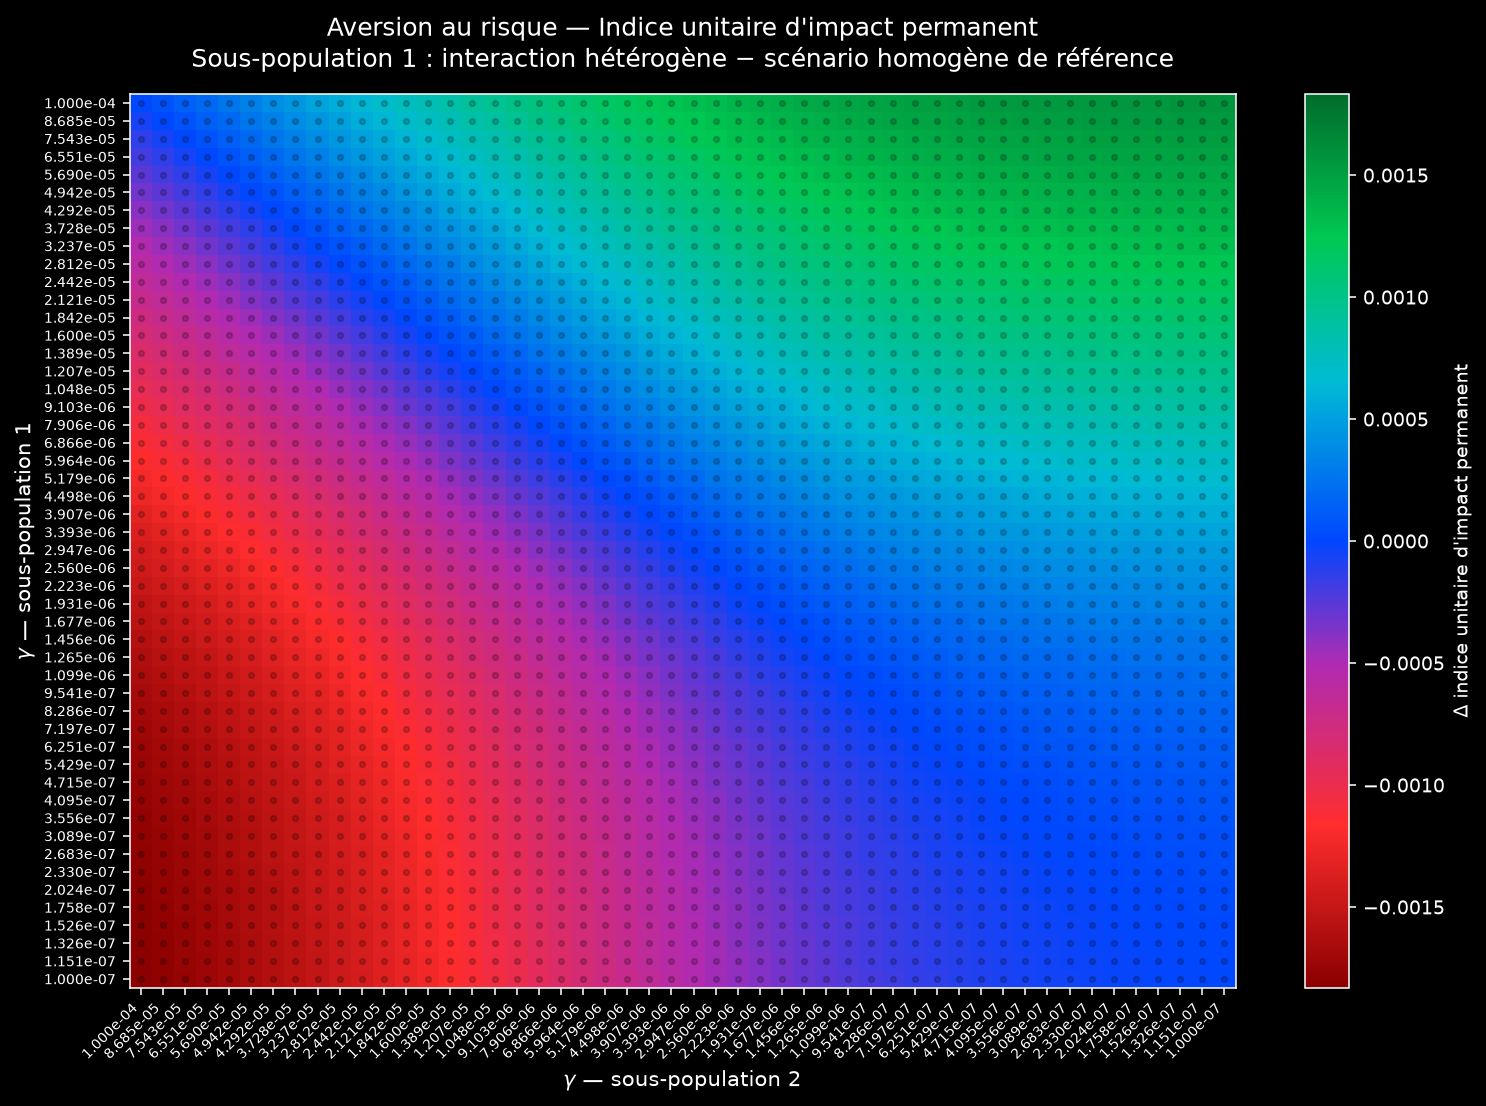

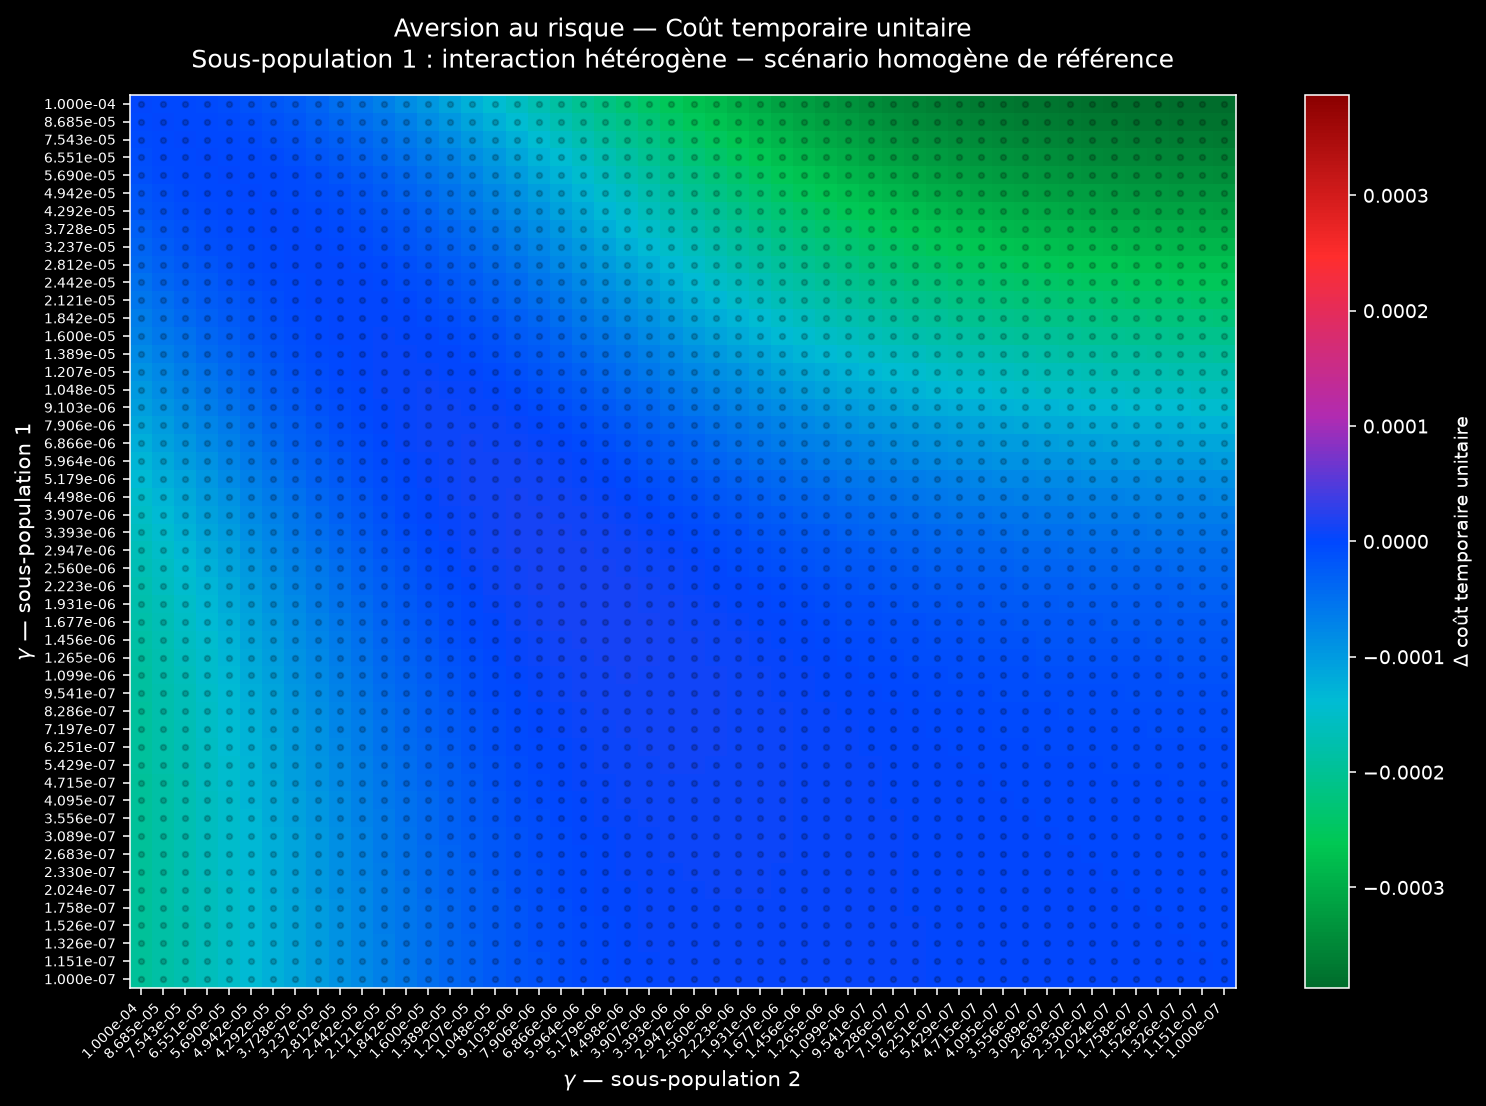

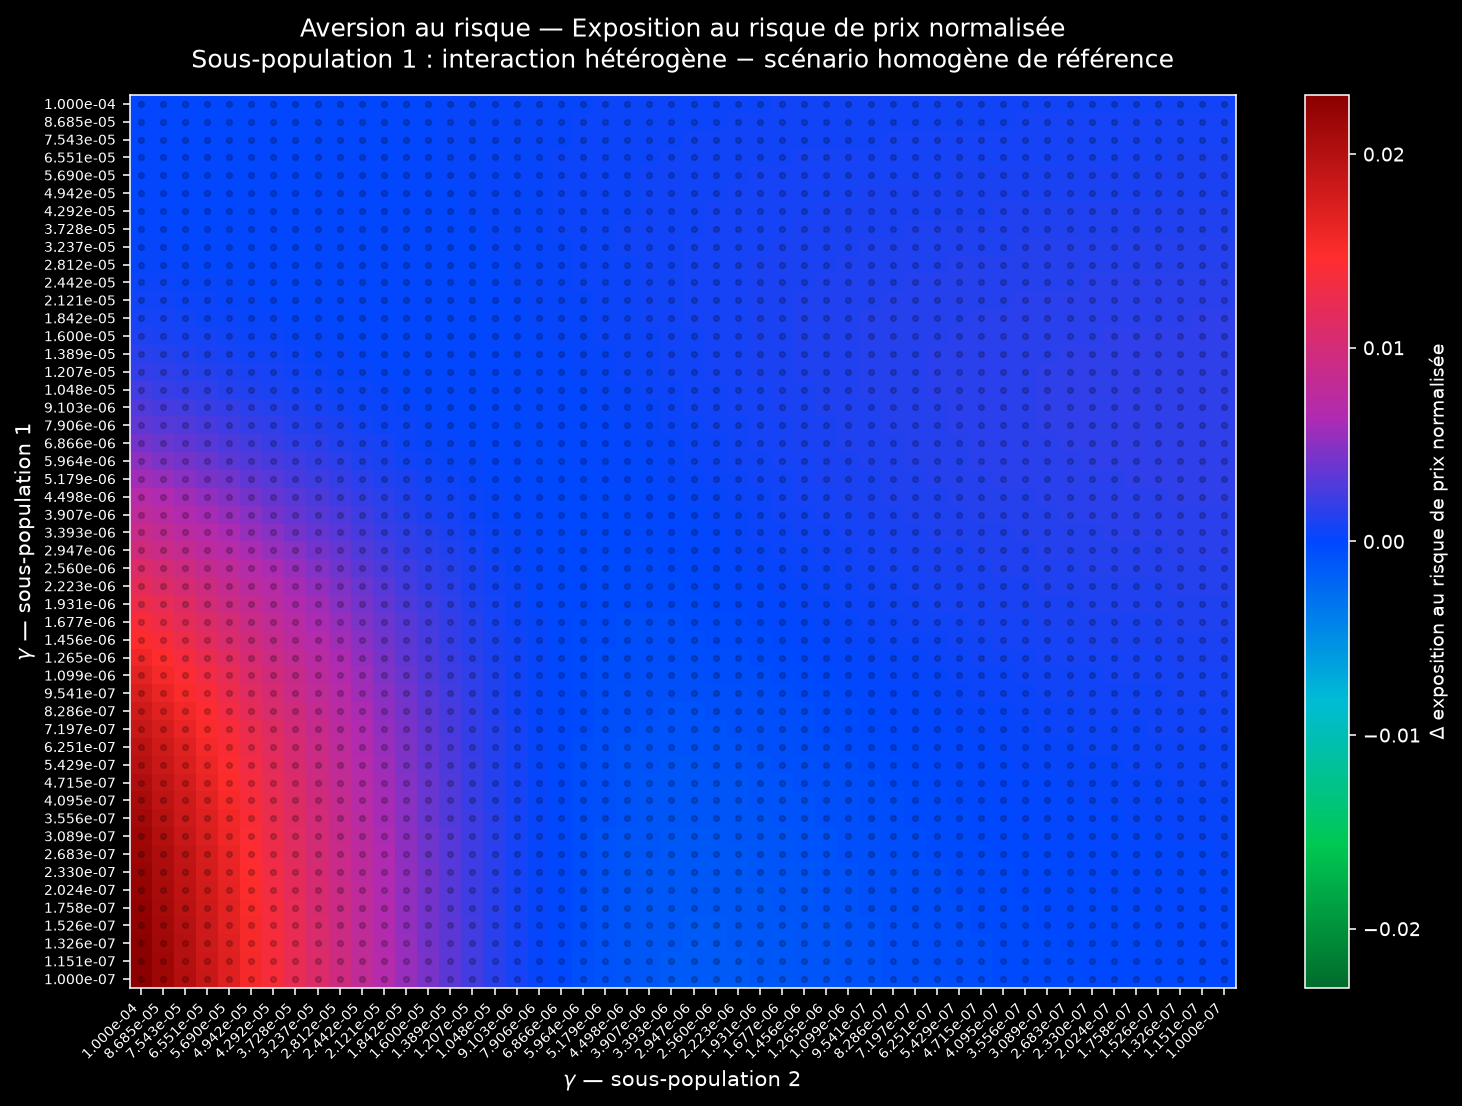

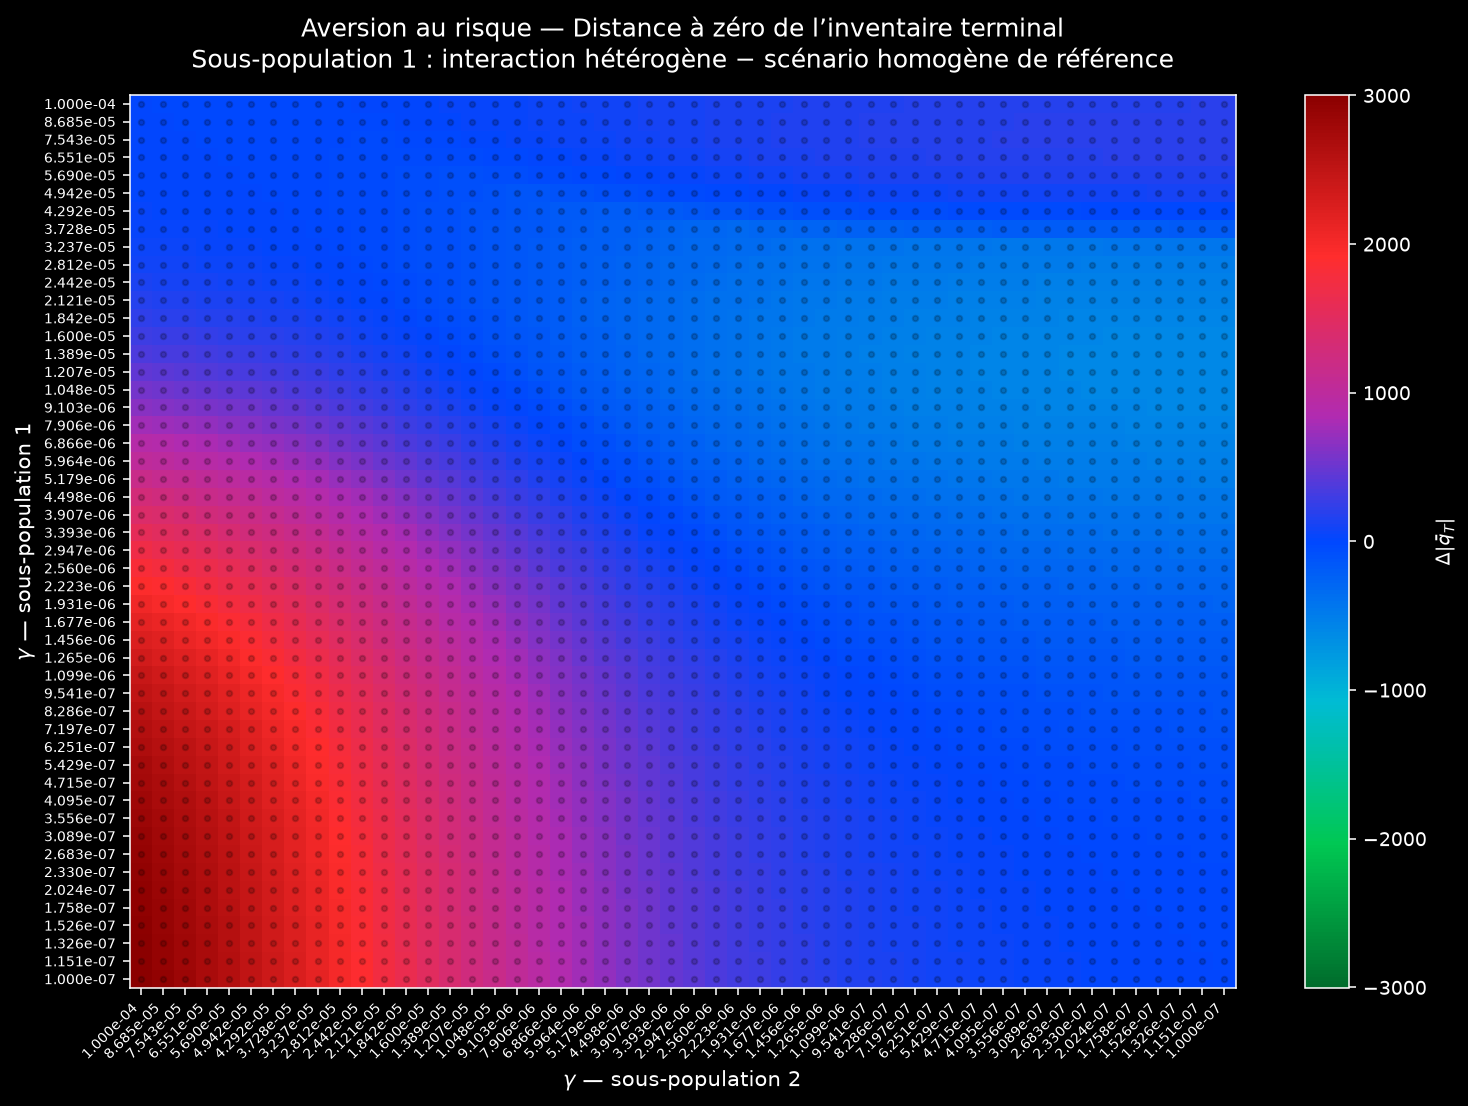

Pénalisation de l'inventaire terminal


,scenario,metric,max_abs_diagonal,within_tolerance
0,aversion_inventaire_terminal_A,delta_pop1_permanent_impact_unit,0.0,True
1,aversion_inventaire_terminal_A,delta_pop1_temporary_cost_unit,0.0,True
2,aversion_inventaire_terminal_A,delta_pop1_risk_normalized,0.0,True
3,aversion_inventaire_terminal_A,delta_pop1_abs_final_inventory,0.0,True


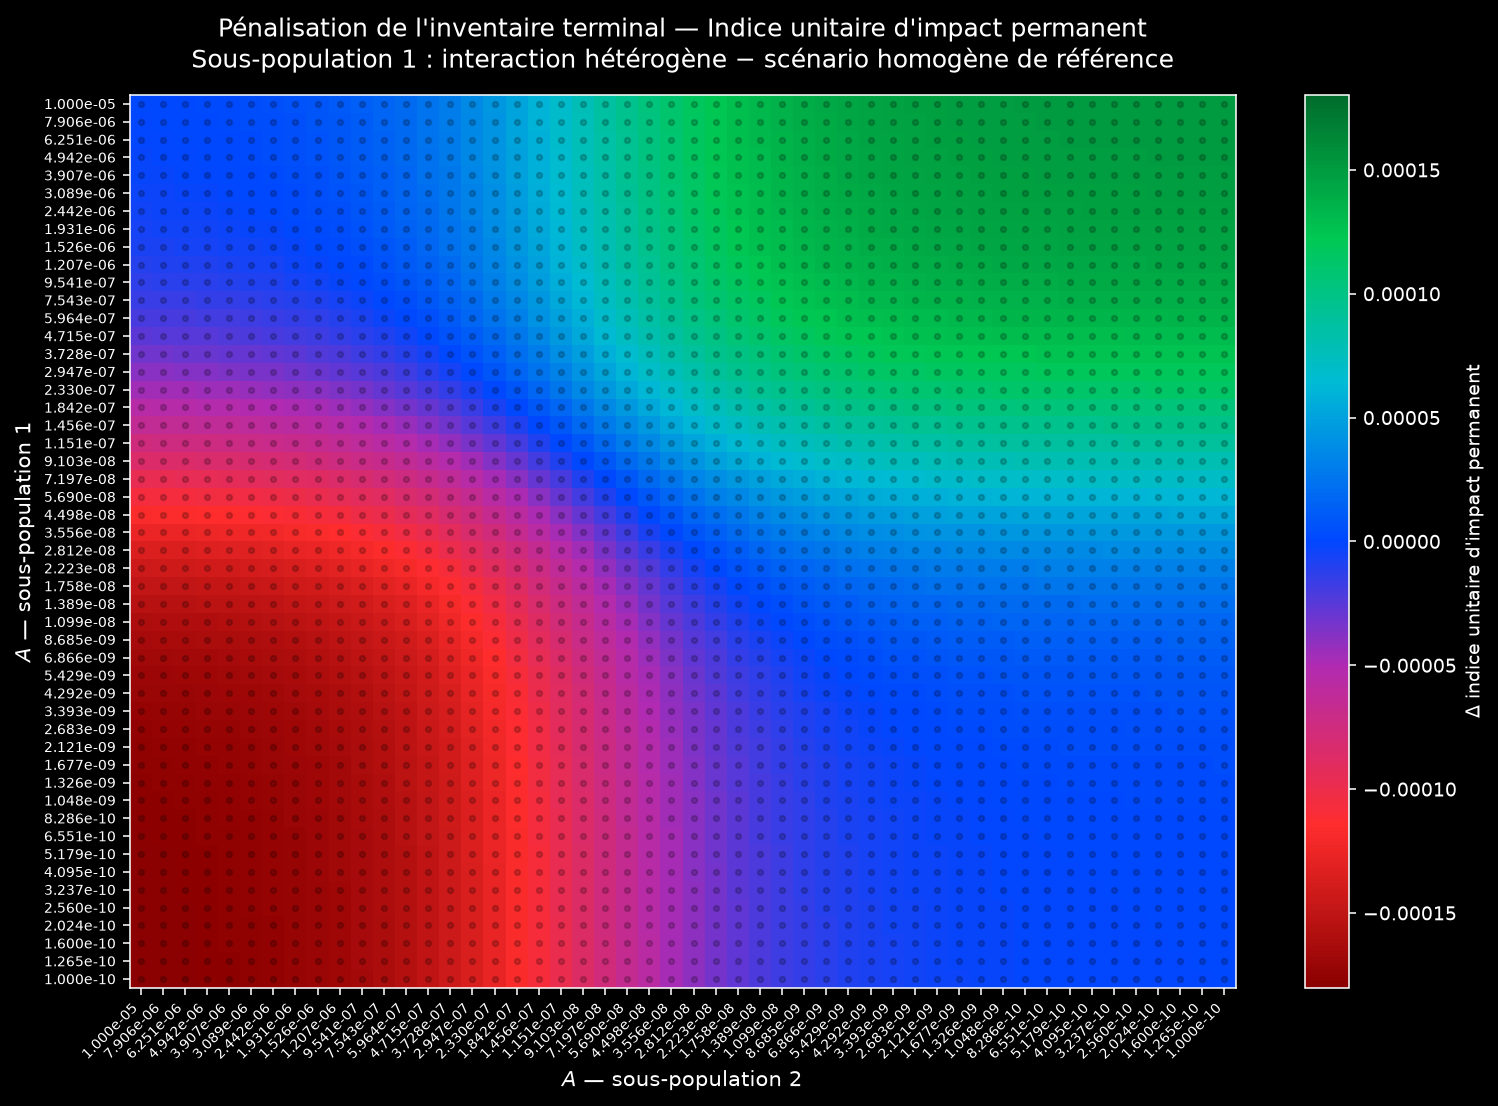

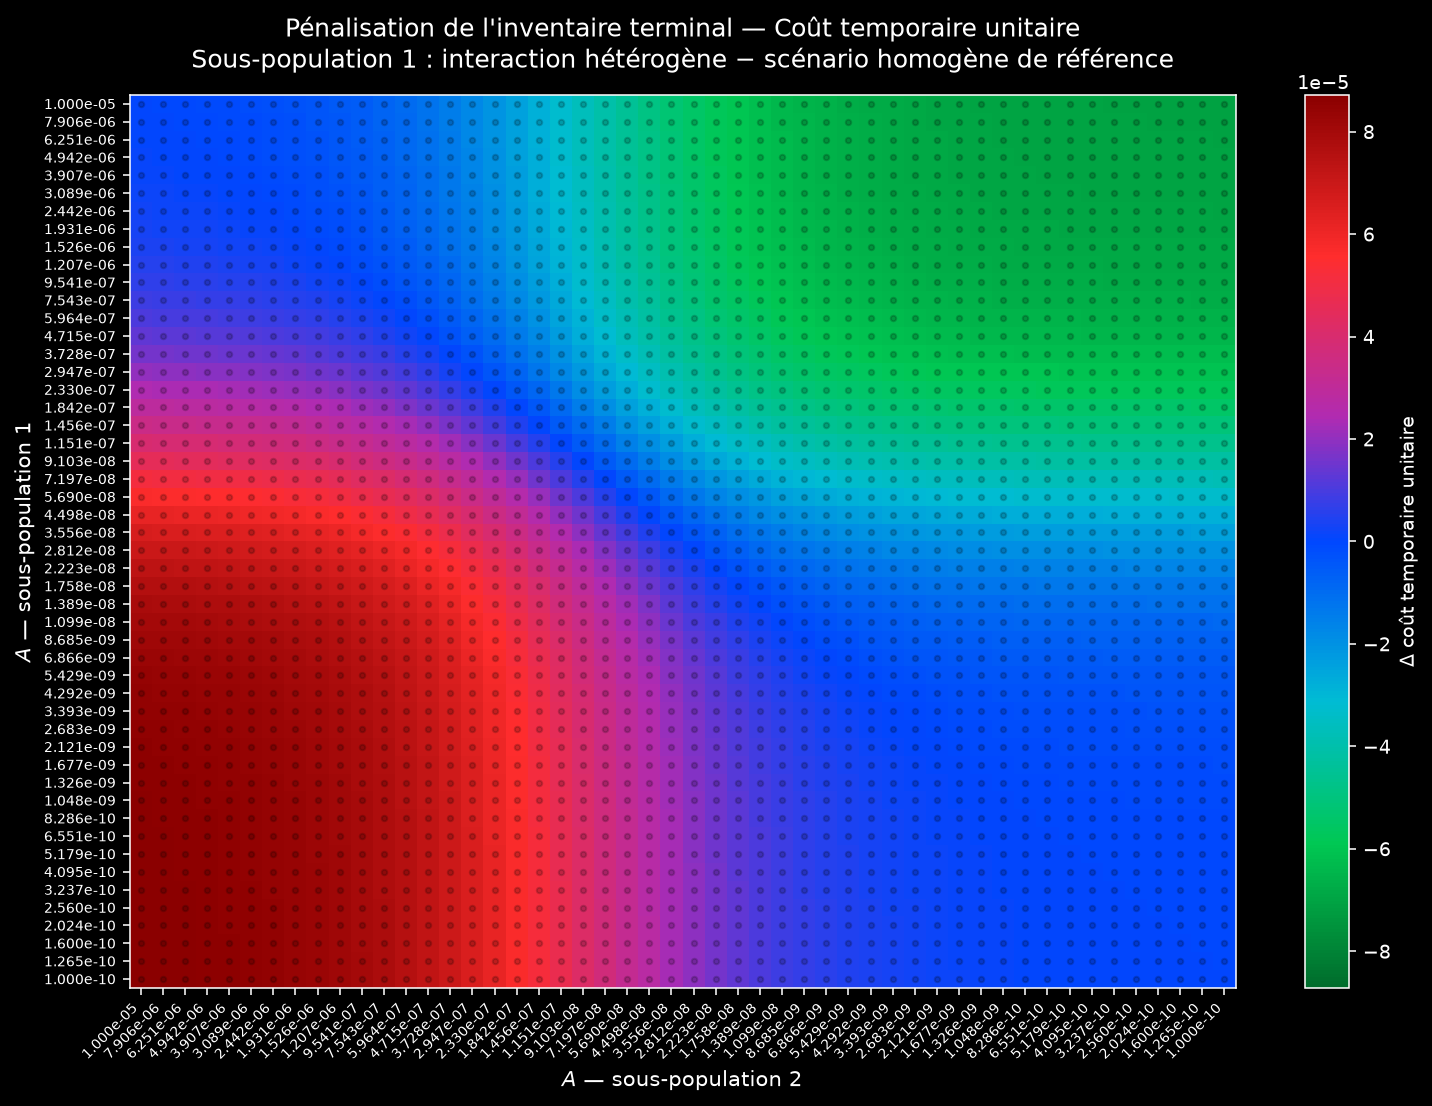

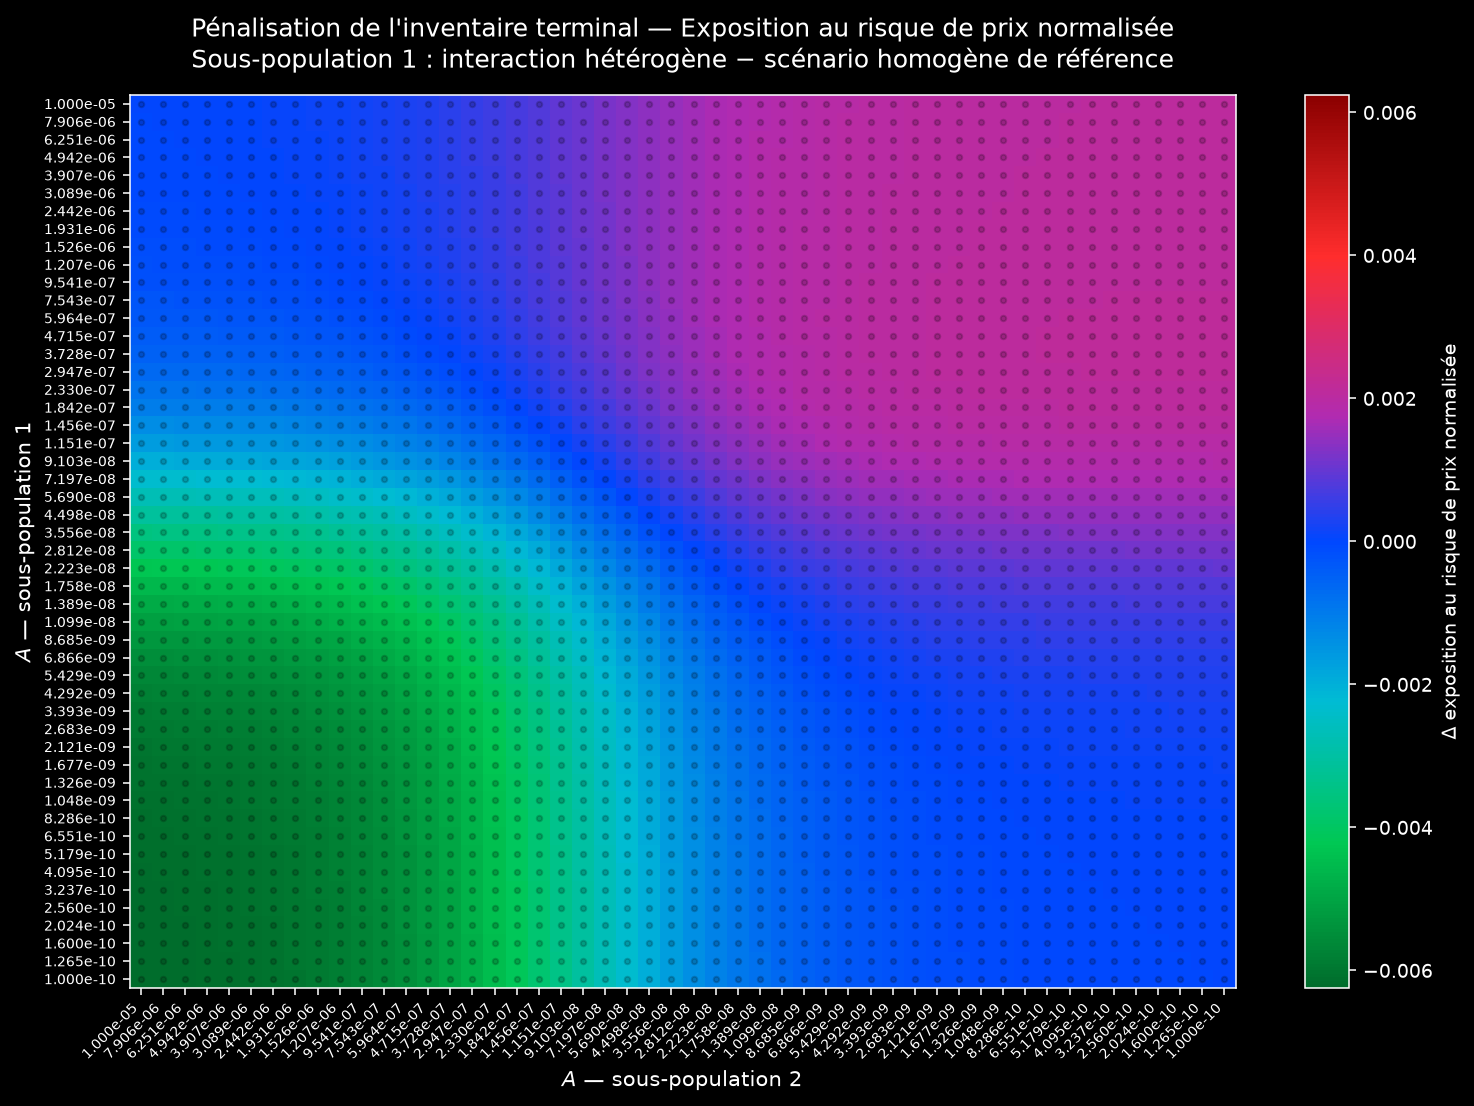

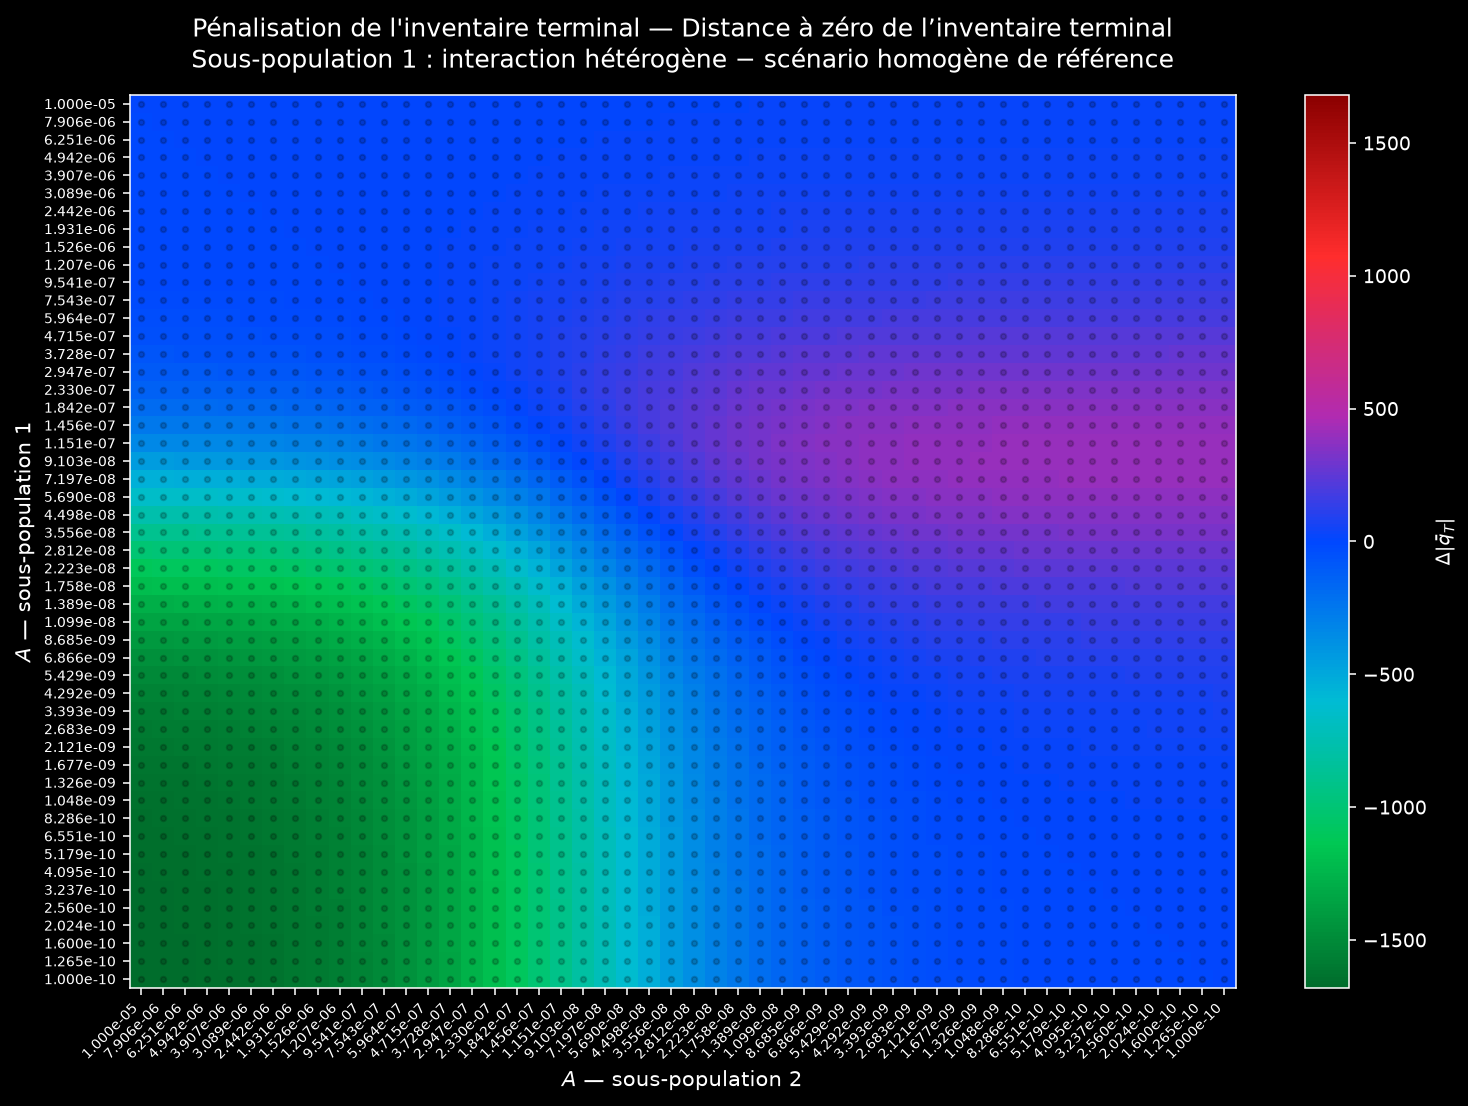

Inventaire initial


,scenario,metric,max_abs_diagonal,within_tolerance
0,inventaire_initial_E0,delta_pop1_permanent_impact_unit,0.0,True
1,inventaire_initial_E0,delta_pop1_temporary_cost_unit,0.0,True
2,inventaire_initial_E0,delta_pop1_risk_normalized,0.0,True
3,inventaire_initial_E0,delta_pop1_abs_final_inventory,0.0,True


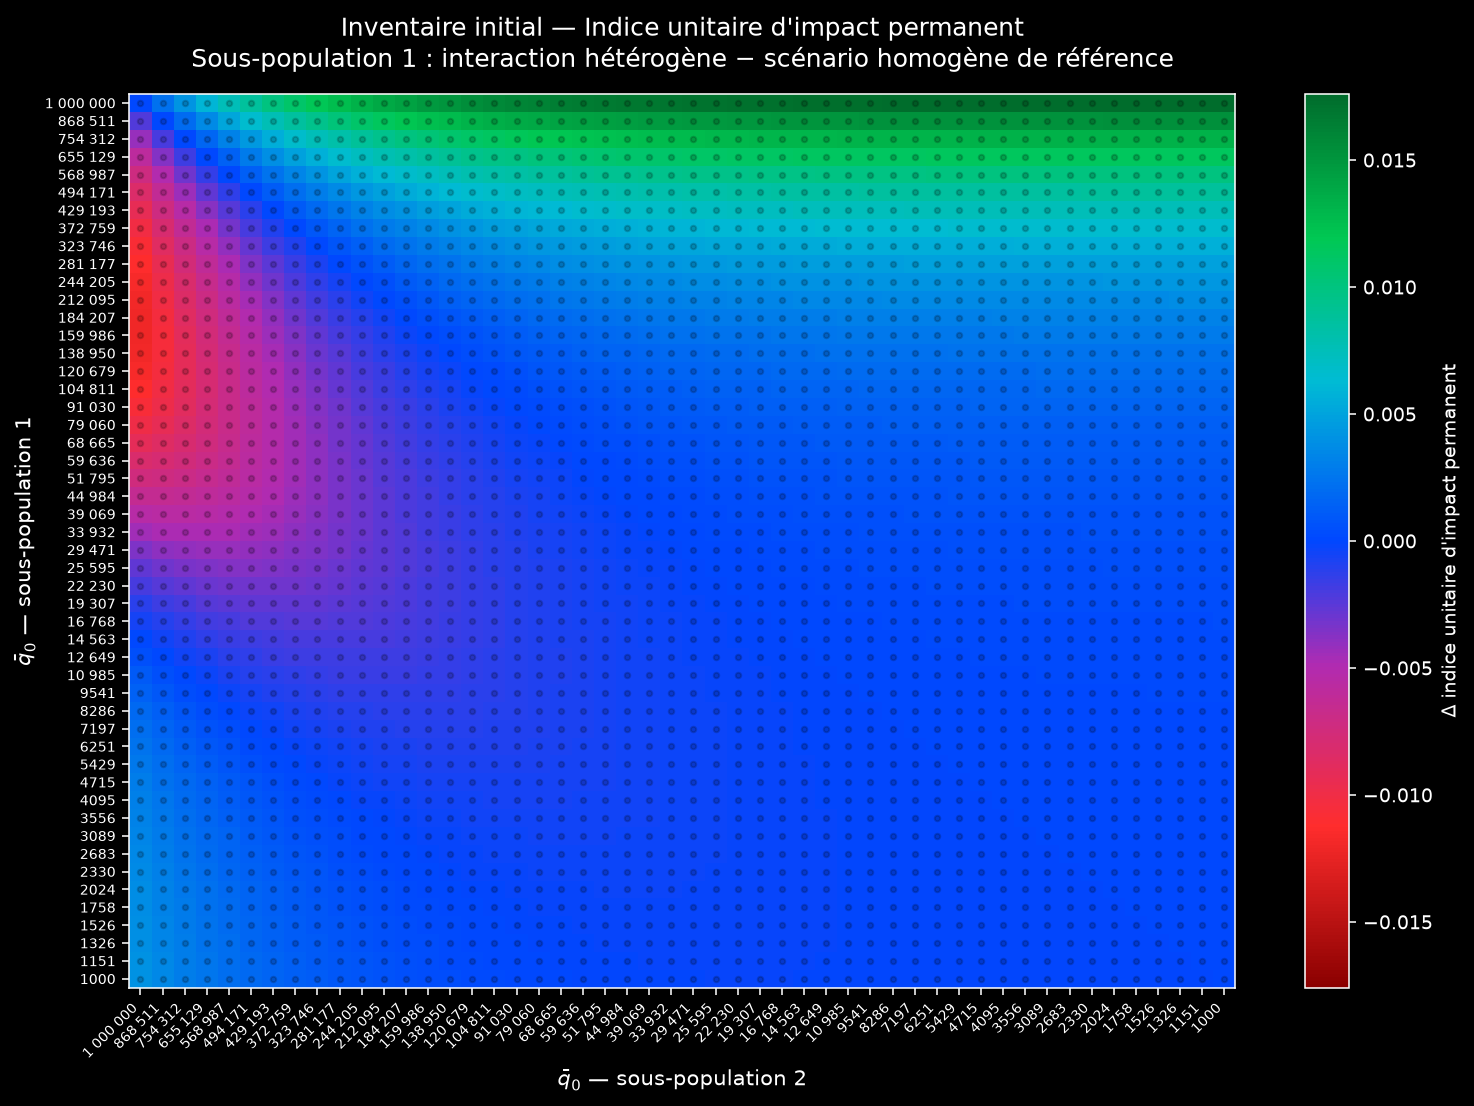

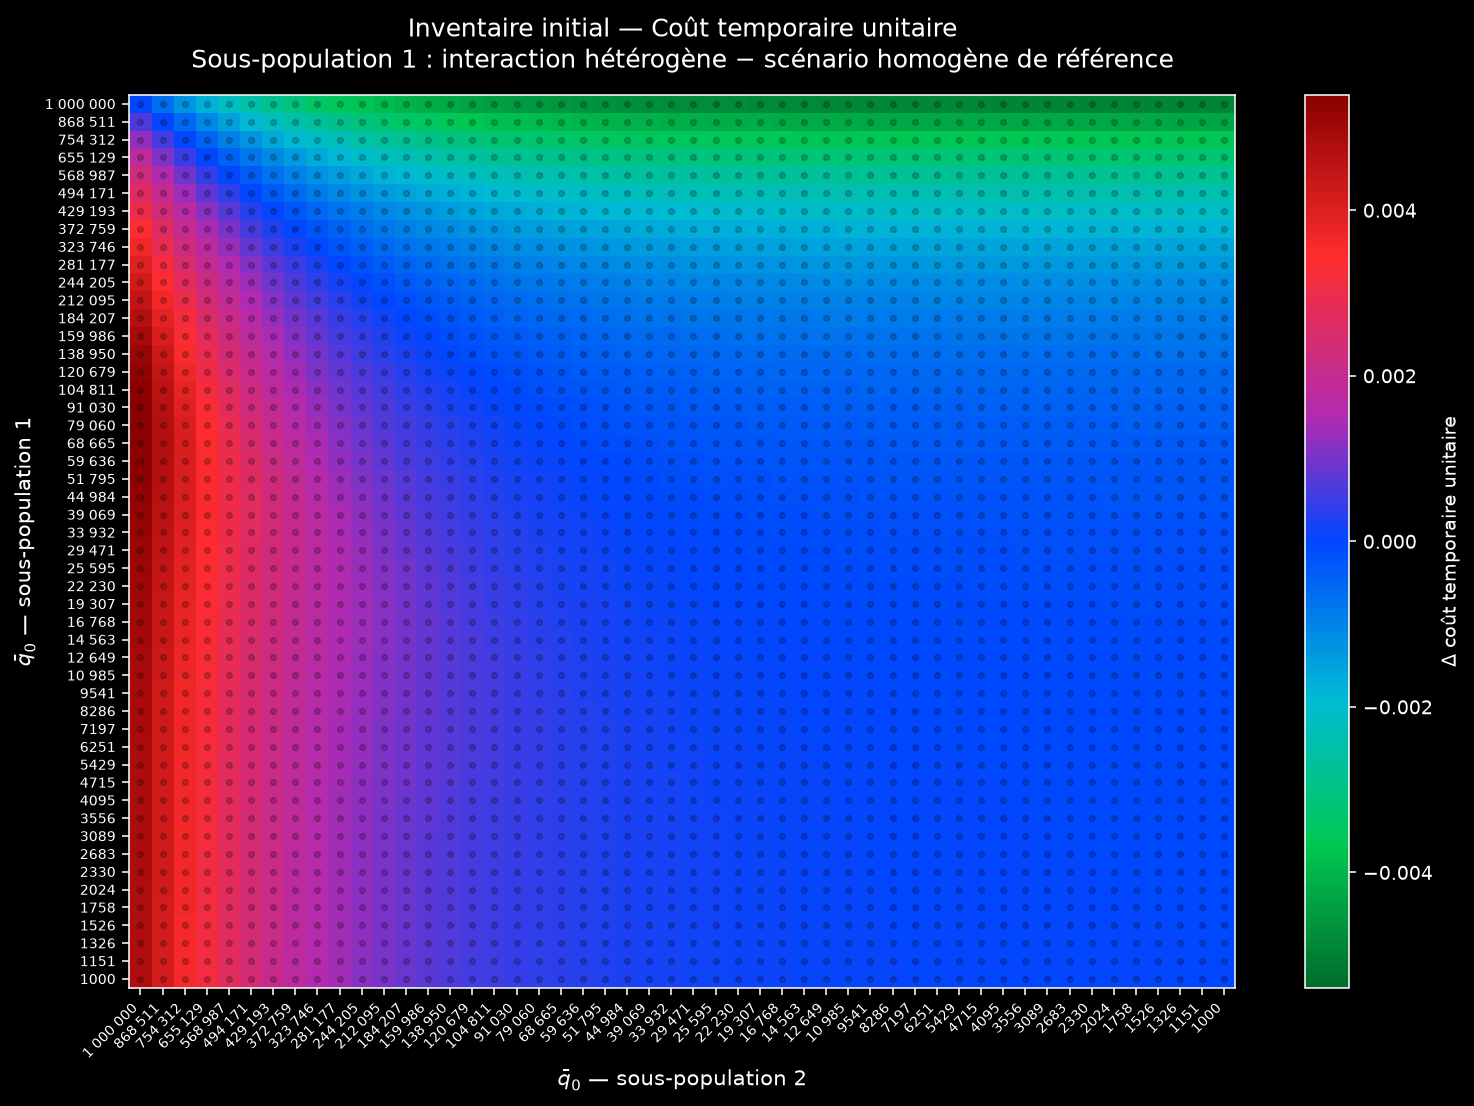

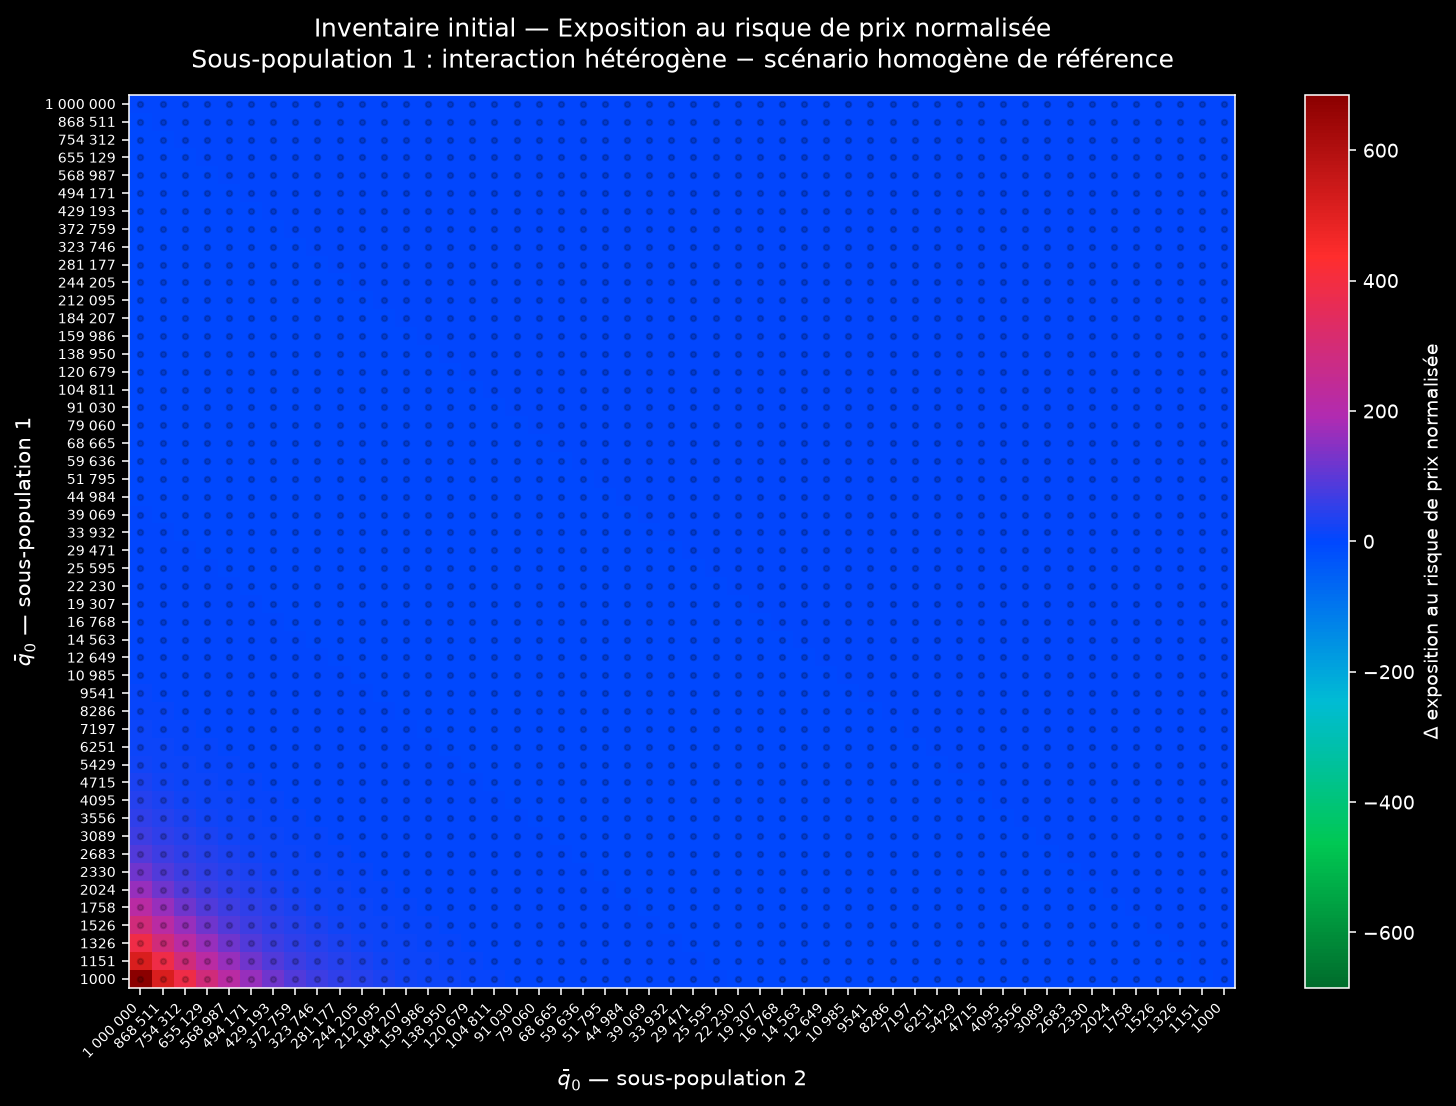

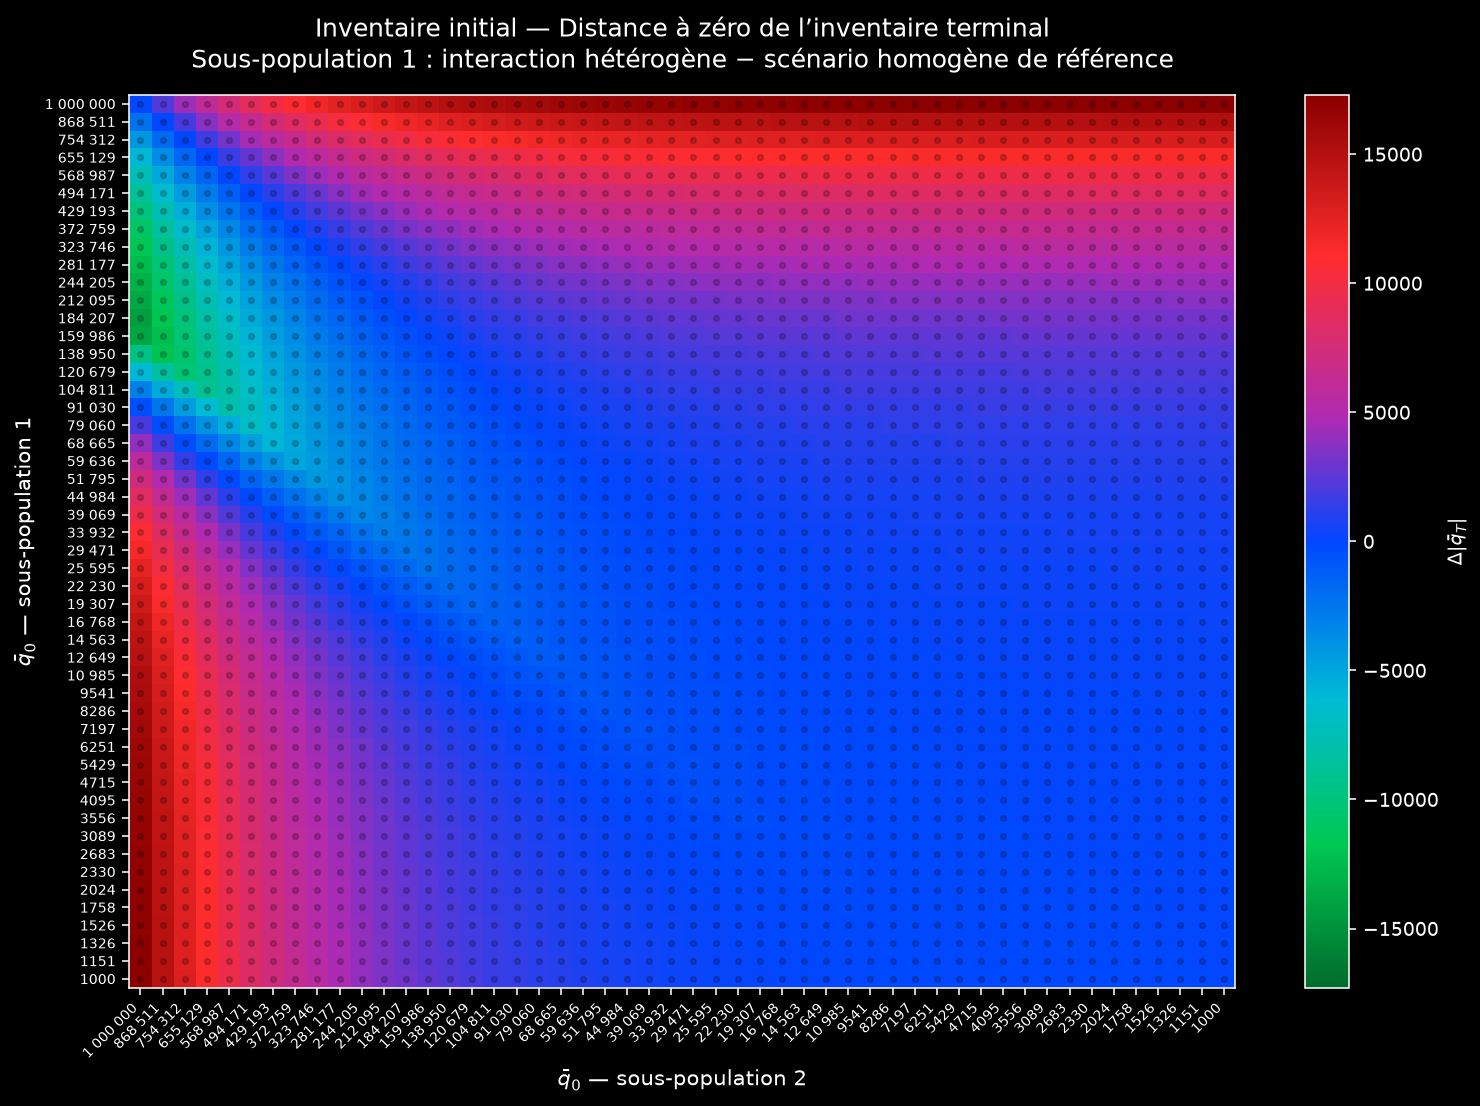

Calcul complet terminé.


In [3]:
all_results = []
validation_tables = []

for scenario in HEATMAP_SCENARIOS:
    print("=" * 90)
    print(scenario.title)
    df, y_values, x_values = run_scenario_grid(scenario)
    all_results.append(df)

    raw_csv = RAW_DIR / f"{scenario.key}_interaction_vs_reference_homogene_resultats_complets.csv"
    df.to_csv(raw_csv, index=False, encoding="utf-8-sig")

    validation = diagonal_validation(df)
    validation.insert(0, "scenario", scenario.key)
    validation_tables.append(validation)
    validation.to_csv(
        RAW_DIR / f"{scenario.key}_validation_diagonale.csv",
        index=False,
        encoding="utf-8-sig",
    )
    display(validation)

    for spec in HEATMAP_SPECS:
        matrix = matrix_from_results(df, spec.result_column, y_values, x_values)
        save_matrix_csv(
            matrix, y_values, x_values,
            FIGURE_DIR / f"{scenario.key}_heatmap_delta_{spec.key}.csv",
        )
        plot_heatmap_delta(
            matrix, y_values, x_values, scenario, spec,
            FIGURE_DIR / f"{scenario.key}_heatmap_delta_{spec.key}.svg",
            annotate=False, show=True,
        )

pd.concat(all_results, ignore_index=True).to_csv(
    RAW_DIR / "tous_les_resultats_interaction_vs_reference_homogene.csv",
    index=False, encoding="utf-8-sig",
)
pd.concat(validation_tables, ignore_index=True).to_csv(
    RAW_DIR / "validation_diagonales.csv",
    index=False, encoding="utf-8-sig",
)
print("Calcul complet terminé.")